# End of Snowball Earth: Climate model with a bifurcation

This notebook introduces a **simple climate model** to explore the rapid warming at the end of a hypothesized Snowball Earth period. In our model of the Earth's climate, we conceive of the Earth's surface and atmosphere as a single reservoir. The surface temperature is determined by the balance of incoming and outgoing radiation. The model accounts for:

1. The greenhouse effect
2. The temperature-dependent snow and ice cover, which in turn controls how much sunlight is reflected and is thus not available to warm the surface

It is a simplified version of the classic models by Sellers and Budyko. A gentle introduction to one-reservoir energy balance models can be found [here](https://doi.org/10.48550/arXiv.1907.11067).

We will use this model to explore the **Snowball Earth hypothesis**. Specifically, we will test whether the model can reproduce the kind of drastic climate shift proposed by this hypothesis: namely, how the gradual emission of greenhouse gases by volcanoes could induce a catastrophic transition from a Snowball Earth state to a largely ice-free state.

The predicted sudden shift is due to a **bifurcation**, also referred to as a tipping point. At the bifurcation, a small change in a parameter value — in our case, the magnitude of the greenhouse effect — completely changes the dynamics of the system. The sudden change is enabled by a strong positive feedback: as temperature increases, ice melts, causing the Earth's surface to absorb more sunlight, thus increasing temperatures further.

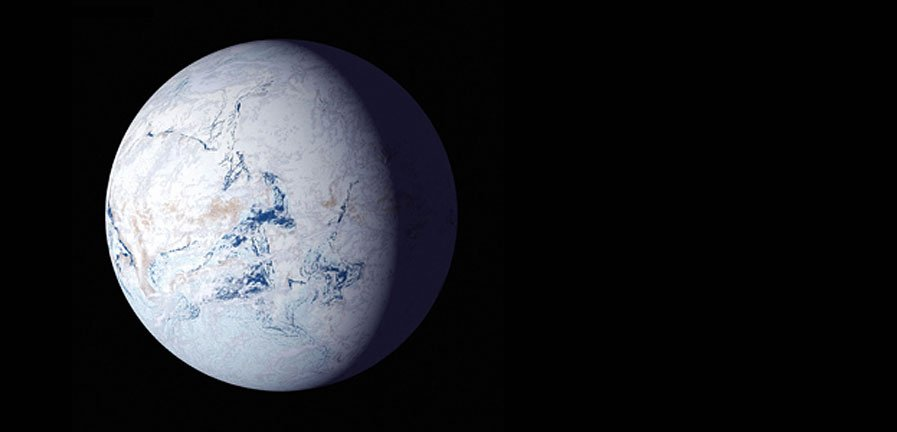

*Artist's depiction of Snowball Earth, from* [NASA Astrobiology](https://astrobiology.nasa.gov/news/fossils-explain-how-life-coped-during-snowball-earth/)

## Climate model

Our model is implemented in Python. We first need to load various packages and set parameters.

Don't worry about the parameters just yet. We will introduce them step by step below.

In [ ]:
import numpy as np
from scipy.constants import Stefan_Boltzmann as sigma
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from collections.abc import Iterable

# Constants
year = (60 * 60 * 24 * 365.25) # seconds in a year
T0 = 273.15 # 0 Celsius in K

# Model parameters
C = 4e8  # [J m-2 K-1] effective heat capacity per unit area
albedo_snow = 0.75 # [-]
albedo_nosnow = 0.25 # [-]
T_half = 255 # half the earth is snow/ice covered at this temperature
T_range = 15 # temperature range over which ice cover transitions from 0 to 1
emiss = 0.67 # [-]; emissivity
S0 = 342 # [W m-2]; spatially and temporally averaged incoming radiation flux [per unit area], accounting for night

### Energy balance of the Earth's surface

The **control volume** of our reservoir encompasses the atmosphere and the Earth's surface. We would like its average temperature to be representative of the average temperature at the surface, while bearing in mind there are [substantial limitations](https://doi.org/10.5194/esd-11-1195-2020) to describing the Earth's climate using a single reservoir.

**Conservation of energy** underpins our climate model. We will track the reservoir's internal energy $U$ through the energy balance. This is similar to the mass balance we used in our hydrological model. As in the hydrological model, it will be easier to normalize physical quantities by the total surface area.

> ⚖️ **Energy Balance Equation**
>
> $\displaystyle\frac{\mathrm{d}U}{\mathrm{d}t} = S_{\mathrm{abs}} - S_{\mathrm{em}}$
>
> Where:
> - 🔋 $U$: internal energy per unit surface area [J m$^{-2}$]
> - 📥 $S_{\mathrm{abs}}$: absorbed solar radiation [W m$^{-2}$]
> - 📤 $S_{\mathrm{em}}$: emitted thermal radiation [W m$^{-2}$]

Here, $S_{\mathrm{abs}}$ is the inflow of energy through the absorption of solar radiation (mainly in the visible and near-infrared part of the spectrum). The outflow is given by $S_{\mathrm{em}}$, the emitted radiation (in the longwave infrared). These quantities refer to the entire surface of the Earth and are normalized by the total surface area, so that they represent average radiative fluxes in W m$^{-2}$.

The **change in surface temperature** can be inferred by assuming that a change in temperature $\mathrm{d}T$ corresponds to a change in internal energy $\mathrm{d}U = C\,\mathrm{d}T$, where the proportionality constant $C$ is an effective heat capacity per unit area. Thus:

> 🌡️ **Temperature Evolution Equation**
>
> $\displaystyle C\,\frac{\mathrm{d}T}{\mathrm{d}t} = S_{\mathrm{abs}} - S_{\mathrm{em}}$
>
> Where:
> - 🌡️ $T$: surface temperature [K]
> - 🔥 $C$: effective heat capacity per unit area [J m$^{-2}$ K$^{-1}$]
> - 📥 $S_{\mathrm{abs}}$: absorbed solar radiation [W m$^{-2}$]
> - 📤 $S_{\mathrm{em}}$: emitted thermal radiation [W m$^{-2}$]

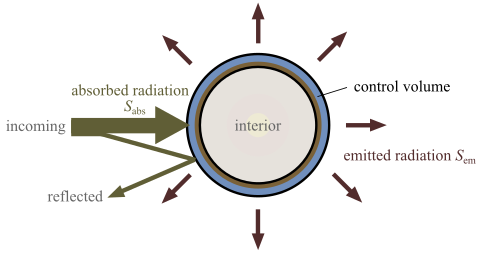

*To model the energy balance of the Earth's atmosphere and surface (control volume), we consider the absorption of incoming solar radiation and the emission of thermal radiation. Exchanges with the Earth's interior are neglected.*

### Absorbed radiation and Earth's albedo

We model the **absorbed radiation** 📥 $S_{\mathrm{abs}}$ as a fraction of the incoming solar radiation at the top of the atmosphere, ☀️ $S_0 = 342\,\mathrm{W\,m^{-2}}$, when averaged over the entire year and the Earth's surface.

The **albedo** governs how much radiation is reflected and how much is absorbed. The albedo — literally, whiteness — is a dimensionless number between 0 and 1, and describes the fraction of incoming radiation that is reflected. A surface with albedo $a$ receiving incoming radiation $S_0$ reflects $a\,S_0$, while the remainder is absorbed:

> 📥 **Absorbed Solar Radiation**
>
> $S_{\mathrm{abs}} = (1 - a)\,S_0$
>
> Where:
> - 🪞 $a$: albedo (brightness of the Earth's surface) [−]
> - ☀️ $S_0$: incoming solar radiation at top of atmosphere [W m$^{-2}$]
> - 📥 $S_{\mathrm{abs}}$: absorbed solar radiation [W m$^{-2}$]

The code box below implements this equation in Python. The function determines the absorbed radiation as a function of temperature `T`, because the albedo depends on temperature.

In [ ]:
def S_abs(T):
    """
    Calculate absorbed solar radiation as a function of temperature.
    Returns the absorbed radiation in W m^-2 based on temperature-dependent albedo.
    """
    return (1 - albedo(T)) * S0

The **albedo depends on temperature** because colder temperatures induce greater snow and ice cover. For simplicity, we assume that for very cold (warm) temperatures essentially the entire Earth is ice-covered (ice-free), with a gradual transition in between. This dependence is essential to the ice–albedo feedback, as an increase in temperature will lower the albedo, increasing $S_{\mathrm{abs}}$.

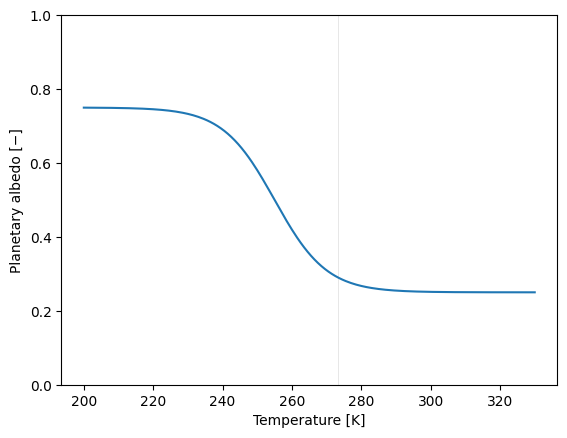

In [ ]:
def albedo(T):
    """
    Calculate temperature-dependent albedo.
    Returns albedo interpolating between ice-covered and ice-free Earth.
    """
    frac = 0.5 * (1 + np.tanh((T - T_half) / T_range))
    return albedo_nosnow * frac + albedo_snow * (1 - frac)

# Plot the albedo dependence on temperature
T_grid = np.linspace(200, 330, num=261)
fig, ax = plt.subplots()
ax.axvline(T0, lw=0.5, c='#dddddd')
ax.plot(T_grid, albedo(T_grid))
ax.set_xlabel('Temperature [K]')
ax.set_ylim((0, 1))
_ = ax.set_ylabel('Planetary albedo [−]')

Snow and ice have a large albedo (they are bright and absorb little radiation). You can change the corresponding parameter `albedo_snow` in the first code cell. You can also play with the snow-free albedo `albedo_nosnow`, the temperature at which half the Earth is ice-covered `T_half`, and the width of the transition `T_range`. The default parameter values are of the right order of magnitude, but it is difficult to constrain the values tightly because this relationship is such an oversimplification.

### Emitted radiation and greenhouse effect

The **emitted radiation** increases with temperature according to the Stefan–Boltzmann law:

> 📤 **Emitted Thermal Radiation**
>
> $S_{\mathrm{em}} = \varepsilon \, \sigma \, T^4$
>
> Where:
> - 📡 $\varepsilon$: emissivity (effectiveness at emitting thermal radiation) [−]
> - 📏 $\sigma$: Stefan–Boltzmann constant = $5.67 \times 10^{-8}$ [W m$^{-2}$ K$^{-4}$]
> - 🌡️ $T$: surface temperature [K]
> - 📤 $S_{\mathrm{em}}$: emitted thermal radiation [W m$^{-2}$]

The emitted radiation increases with $T^4$: doubling the (absolute) temperature corresponds to an increase in emission by a factor of 16. The emissivity $\varepsilon \in [0, 1]$ is a measure of how effective the surface is at emitting thermal radiation.

The **greenhouse effect can be captured through the emissivity** when $\varepsilon < 1$. Very roughly speaking, greenhouse gases such as carbon dioxide "trap" the radiation emitted by the ocean or land surface, reducing the radiation that escapes from the Earth. An increase in greenhouse gases from volcanoes or anthropogenic emissions will reduce $\varepsilon$. This, in turn, will cause the Earth to heat up. To see this, consider that in steady state, the net radiation $$S_{\mathrm{net}} \equiv S_{\mathrm{em}} - S_{\mathrm{abs}} = 0$$
vanishes (in words, absorbed and emitted radiation are in balance). In the simplest case, $S_{\mathrm{abs}}$ will remain constant, so that a decrease in $\varepsilon$ needs to be compensated by an increase in $T$.

In our model, we consider $\varepsilon$ to be a parameter. For modeling the end of Snowball Earth, we will slowly decrease $\varepsilon$ in response to an accumulation of greenhouse gases in the atmosphere.

In [ ]:
def S_em(T, emiss=emiss):
    """
    Calculate emitted thermal radiation using the Stefan–Boltzmann law.
    Returns emitted radiation in W m^-2.
    """
    return emiss * sigma * T ** 4

def net_radiation(T, emiss=emiss):
    """
    Calculate net radiation balance (absorbed minus emitted).
    Returns net radiation in W m^-2.
    """
    return S_abs(T) - S_em(T, emiss=emiss)

### Feedbacks

Our climate model that accounts for the **ice-albedo feedback** is now complete. Based on the energy balance, it describes how the Earth's temperature 🌡️ changes in dependence of the absorbed 📥 and emitted 📤 radiation. The absorbed radiation depends on the albedo 🪞, which in turn depends on temperature. The emitted radiation varies with temperature through the Stefan–Boltzmann law, which also accounts for the greenhouse effect through the emissivity.

Let's draw a **system diagram** to identify the primary feedback loops. We'll include the temperature 🌡️ $T$ in the center, along with the emitted radiation 📤 $S_{\mathrm{em}}$ and the albedo 🪞 $a$ and absorbed radiation 📥 $S_{\mathrm{abs}}$.

### Simulations

We will now **simulate the temperature** over half a century, to get a sense of the climate conditions our model predicts. Your divine intervention will determine the initial temperature $T_0$, but then the Earth system will evolve according to our model. We will keep the greenhouse effect ($\varepsilon$) fixed at, roughly, contemporary values.

For relatively **warm initial temperatures** of $T_0 \approx 270\,\mathrm{K}$, the modeled temperature approaches a steady state of $T \approx 285\,\mathrm{K}$, representative of today's Earth. The adjustment time scale is on the order of a decade.


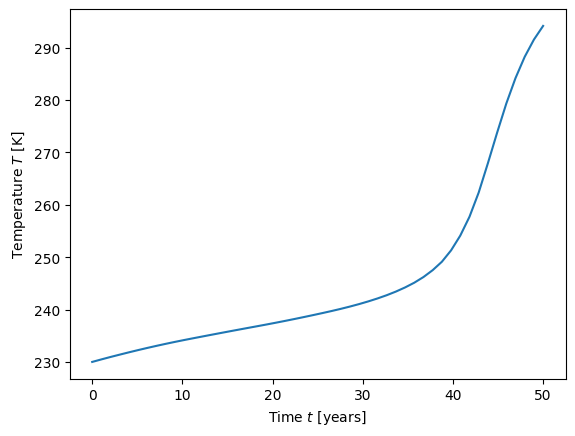

In [ ]:
# TODO: Change the initial conditions
T0 = 270  # initial temperature [K]; default: 270

# Emissivity for simulation
emiss_sim = 0.67  # default: 0.67; do not change for now

# Numerical solution using solve_ivp
t_eval = np.linspace(0, 50 * year, num=50)

def _dTdt(t, T):
    """Right-hand side of temperature evolution equation."""
    return net_radiation(T, emiss=emiss_sim) / C

sol = solve_ivp(
    _dTdt, [t_eval[0], t_eval[-1]], [T0], t_eval=t_eval, method='LSODA')
T = sol.y[0, :]

# Plot temperature evolution
fig, ax = plt.subplots()
ax.plot(t_eval, T)
ax.set_ylabel('Temperature $T$ [K]')
ax.set_xlabel('Time $t$ [years]')
ticks = np.linspace(t_eval[0], t_eval[-1], num=6)
ax.set_xticks(ticks)
_ = ax.set_xticklabels((ticks / year).astype(int))


> 🤝 **In pairs: Explore Different Initial Conditions**
>
> **Instructions:** Change the initial temperature `T0` in the code above and observe how the temperature evolves over time. Try values that are very warm (e.g., $T_0 \approx 310\,\mathrm{K}$), moderate (e.g., $T_0 \approx 280\,\mathrm{K}$), and very cold (e.g., $T_0 \approx 230\,\mathrm{K}$).
>
> **Questions:**
> 1. **Final state:** What happens for very warm initial temperatures? What happens for very cold initial temperatures? Where does the temperature end up in each case?
> 2. **Multiple equilibria:** Does the system always approach the same steady state, or does the final state depend on the initial condition?
> 3. **Physical interpretation:** How could this behavior be explained in terms of the albedo feedback and energy balance?
>
> In addition to the simulated dynamics, you can also consider the energy balance equation and the physical mechanisms (albedo, greenhouse effect) we included in the model.

## Steady state solutions

Our model permits multiple steady states for the chosen emissivity, as revealed by your previous experiments. These include a warm world with little ice cover and a cold snowball world, with high and low albedo, respectively. But are these all possible steady states?

In **steady state**, the inflow of energy $S_{\mathrm{abs}}$ equals the outflow $S_{\mathrm{em}}$. In our model, inflow and outflow depend on temperature $T$. We can see for which temperatures $S_{\mathrm{abs}} = S_{\mathrm{em}}$ by plotting them against $T$.

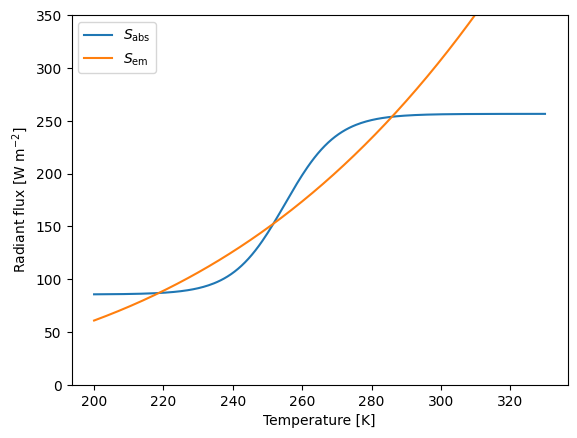

In [ ]:
# Calculate absorbed and emitted radiation over temperature range
S_abs_grid = S_abs(T_grid)
S_em_grid = S_em(T_grid, emiss=emiss_sim)

# Plot inflow and outflow vs temperature
fig, ax = plt.subplots()
ax.plot(T_grid, S_abs_grid, label=r'$S_{\mathrm{abs}}$')
ax.plot(T_grid, S_em_grid, label=r'$S_{\mathrm{em}}$')
ax.set_ylim((0, 350))
ax.set_ylabel('Radiant flux [W m$^{-2}$]')
ax.set_xlabel('Temperature [K]')
_ = ax.legend(loc='upper left')

**The curves intersect at three points, each corresponding to a steady-state solution.** If the temperature starts out at one of these points, it will remain unchanged indefinitely. In other words, there exists a steady state. To see this, note that $S_{\mathrm{abs}} = S_{\mathrm{em}}$ implies vanishing net radiation $S_{\mathrm{net}} \equiv S_{\mathrm{abs}} - S_{\mathrm{em}} = 0$, so that
$$C\,\frac{\mathrm{d}T}{\mathrm{d}t} = S_{\mathrm{net}} = 0.$$
In this case, the temperature $T$ does not change.

In dynamical systems theory, we also call these points at which the time derivative vanishes **fixed points**.

### Stability

These three fixed points are qualitatively different. You will notice that your earlier simulations converged to the one near 220 K and the one near 280 K, but not to the one in the middle near 260 K. This is because the first two are **stable fixed points**, while the one in the middle is an **unstable fixed point**.

Whether a fixed point is stable or not depends on the sign of the net radiation if the temperature is perturbed slightly away from the fixed point.

**Stable fixed points** attract nearby trajectories. Consider the rightmost fixed point near 285 K. Imagine the temperature were 300 K, higher than the fixed point. We see that the emitted radiation (orange) is larger than the absorbed radiation (blue): the net radiation $S_{\mathrm{net}} < 0$, causing the temperature to decrease ($\mathrm{d}T/\mathrm{d}t < 0$). We indicate this at the bottom of the plot with an arrow pointing to the left, i.e., toward lower temperatures. The temperature will continue to decrease until it reaches the fixed point. Similarly, for $T = 280\,\mathrm{K}$ just below the fixed point, the net radiation is positive and the temperature will increase until it reaches the fixed point. The same reasoning applies to the leftmost fixed point.

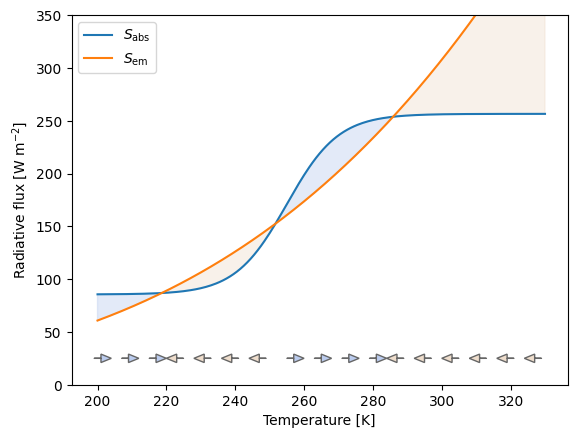

In [ ]:
# Create stability diagram with shaded regions
fig, ax = plt.subplots()
arrow_colors = {1: '#bbccee', -1: '#eeddcc'}  # 1: warming (blue), -1: cooling (orange)

# Plot absorbed and emitted radiation
ax.plot(T_grid, S_abs_grid, label=r'$S_{\mathrm{abs}}$')
ax.plot(T_grid, S_em_grid, label=r'$S_{\mathrm{em}}$')

# Shade regions based on sign of net radiation
ax.fill_between(
    T_grid, S_em_grid, S_abs_grid, where=(S_em_grid > S_abs_grid),
    color=arrow_colors[-1], alpha=0.4)
ax.fill_between(
    T_grid, S_abs_grid, S_em_grid, where=(S_abs_grid > S_em_grid),
    color=arrow_colors[1], alpha=0.4)

# Add arrows showing direction of temperature change
direction_grid = np.sign(S_abs_grid - S_em_grid)
for _T, _direction in list(zip(T_grid, direction_grid))[::16]:
    ax.arrow(
        _T - _direction, 25, 2 * _direction, 0, head_width=8, head_length=3,
        fc=arrow_colors[int(_direction)], ec='#666666')

ax.set_ylim((0, 350))
ax.set_ylabel('Radiative flux [W m$^{-2}$]')
ax.set_xlabel('Temperature [K]')
_ = ax.legend(loc='upper left')

The **unstable fixed point** behaves in a different way. Apply analogous reasoning to understand what happens when the temperature is slightly above that of the central fixed point: what is the sign of the net radiation and in which direction is the temperature "pulled"?

# Volcanic emissions and bifurcations

**Bifurcations** occur when fixed points emerge or disappear as an external parameter changes. In our case, the external parameter is the emissivity $\varepsilon$, which slowly decreases due to volcanic activity. A summary of the key ideas can be found [in these lecture notes](https://courses.seas.harvard.edu/climate/eli/Courses/EPS281r/Sources/Snowball/more/notes-energy_balance_0d.pdf).

Let's compute and plot the fixed points and their stability as a function of the emissivity.


### Computing the fixed points

The function in this code box computes the fixed points using brute force. While easy to understand, the method has numerical issues. There are much better ways to do so.

In [ ]:
# Grid of emissivity values to explore
emiss_grid = np.linspace(0.45, 0.85, num=384)

def fixed_points(T_grid, emiss=emiss):
    """
    Find fixed points and their stability for given emissivity values.
    Returns list of (temperatures, stability) tuples for each emissivity.
    """
    def _fixed_points_single(_emiss):
        # Calculate net radiation across temperature grid
        net_grid = net_radiation(T_grid, emiss=_emiss)

        # Find sign changes in net radiation (indicating fixed points)
        sign_changes = np.signbit(net_grid[1:] * net_grid[:-1])

        # Determine stability: stable if net radiation goes from + to -
        s_f = np.signbit(net_grid)[1:][sign_changes]

        # Estimate fixed point temperatures as midpoints where sign changes
        T_f = 0.5 * (T_grid[1:][sign_changes] + T_grid[:-1][sign_changes])
        return T_f, s_f

    return [_fixed_points_single(em) for em in np.atleast_1d(emiss)]

### Plotting the fixed points

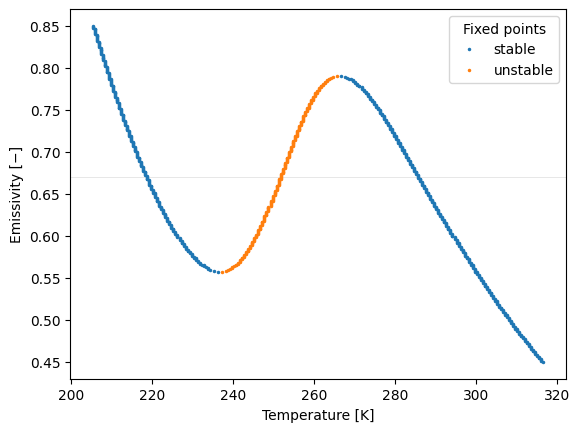

In [ ]:
# Calculate fixed points for all emissivity values
fp = fixed_points(T_grid, emiss=emiss_grid)

# Plot bifurcation diagram
cols = {True: '#1f77b4', False: '#ff7f0e'}  # Blue for stable, orange for unstable
labels = {True: 'stable', False: 'unstable'}

fig, ax = plt.subplots()
handles = {}

# Mark current emissivity value
ax.axhline(emiss, c='#dddddd', lw=0.5)

# Plot all fixed points
for _emiss, _fp in zip(emiss_grid, fp):
    for _T, _s in zip(*_fp):
        handles[_s] = ax.plot(
            _T, _emiss, linestyle='none', marker='o', ms=1.5, c=cols[_s],
            label=labels[_s])[0]

ax.legend(handles=handles.values(), title='Fixed points')
ax.set_ylabel('Emissivity [−]')
_ = ax.set_xlabel('Temperature [K]')

We have created a **bifurcation diagram**. To make it easier to compare with the previous plots, we're showing the parameter on the vertical axis and the state on the horizontal axis, a deviation from the bifurcation diagrams we looked at earlier.

Let's start with the baseline emissivity we looked at just before, shown by a horizontal line. We see that it intersects the curve three times, each intersection corresponding to a fixed point. The left- and right-most are stable; the one in the middle is unstable.

**Bifurcations** arise as we change the emissivity. Assume the emissivity increases gradually (moving upward on the plot). The unstable point and the rightmost stable point approach each other. At some point, these two fixed points will coincide and disappear: a bifurcation.

😱 Mathematicians distinguish different types of bifurcations. The one we just discovered is called a **fold bifurcation** or, equivalently, **saddle-node bifurcation**. Jeffrey Chasnov's online textbook contains a concise mathematical [introduction to one-dimensional bifurcations](https://math.libretexts.org/Bookshelves/Differential_Equations/Differential_Equations_(Chasnov)/08%3A_Nonlinear_Differential_Equations/8.02%3A_One-Dimensional_Bifurcations).

### Sudden changes

A fold bifurcation predisposes a modeled system to **catastrophes**, that is, sudden changes, as the external parameter (emissivity) varies. Imagine a hothouse world with a mean (steady-state) temperature of 280 K and an emissivity of around 0.7. As the emissivity gradually increases (weaker greenhouse effect), the steady-state temperature (corresponding to the stable fixed point) will gradually decrease. Until the bifurcation is reached. At this point, the stable equilibrium disappears, and our system will be drawn to the left, i.e., to lower temperatures. According to our model, we expect a Snowball Earth to form.




## The end of Snowball Earth

According to the Snowball Earth hypothesis, average temperatures on the order of 220 K once prevailed, and large parts of the Earth were frozen. This stable steady state was enabled by the high albedo of snow and ice. Such cold temperatures are not amenable to the efficient removal of carbon dioxide from the atmosphere through weathering or photosynthesis. Instead, CO2 concentrations increased over time, driven by volcanic emissions, which slowly strengthened the greenhouse effect. Temperatures increased gradually up to a point, at which a rapid transition to high temperatures $\gtrsim 270\,\mathrm{K}$ occurred.

> 🤝 **Group activity: Modeling the End of Snowball Earth**
>
> **Instructions:** In groups of three to four, explain how volcanic activity could have pushed our planet out of the surmised Snowball state, according to our climate model. Use the bifurcation diagram and simulations to answer the following questions.
>
> **Questions:**
> 1. **Initial conditions:** Assume a temperature of 220 K at peak Snowball Earth corresponded to a stable steady state. What emissivity does it correspond to? Does that emissivity also permit a snow-free stable state?
> 2. **Quasi-static evolution:** Imagine greenhouse gas concentrations increased gradually, on time scales much longer than the response time of our model. If the system is at a stable steady state and the emissivity changes slowly, we can expect it to remain along that branch of stable steady states. You can use the model to test these expectations. Create a sketch of the system's trajectory on top of the bifurcation diagram.
> 3. **Crossing the bifurcation:** Extend your sketch to show what happens as a bifurcation is approached and crossed. You are encouraged to return to the simulations at the beginning of the notebook: adjust the initial temperature and emissivity according to your needs. Explain in simple terms what Earth system processes captured by our model promoted the system's behavior.
> 4. **Hysteresis:** Imagine that after the system has crossed the bifurcation, the emissivity were to increase again. Sketch the trajectory in a different color. Characterize the behavior of the system.

## In-class experiment: Buckling

Buckling provides another example of a **bifurcation in Earth System Science**, as it is implicated in volcanic and tectonic deformation, or the deformation of sea ice.

In everyday life, you can see it when you press down on a business card, a flyer, or an acrylic ruler. If you only press down a little, the object will remain straight and vertical. As you increase the pressure, at some point the object will deflect to one side.

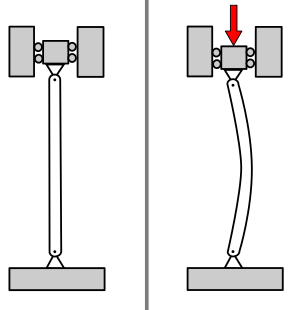

[*Buckling of a beam*](https://commons.wikimedia.org/wiki/File:Buckled_column.svg). *Initially, the beam is vertical, even under application of an axial load at the top. As the load is increased, the beam will eventually buckle to the side, a bifurcation. The horizontal position of either end does not change in this experiment, but there will be a non-zero average deflection when the beam has buckled.*


> 📝 **Take-Home Exercise: Buckling Bifurcation**
>
> **Materials:** A business card (or similar rigid but flexible card)
>
> **Task:** Explore the buckling behavior of the card by slowly varying the force with which you push down on it.
>
> **Instructions:**
> 1. **Observe:** Note how the card behaves as you slowly increase and decrease the applied force. Pay attention to sudden changes in deflection.
> 2. **Create a bifurcation diagram:** Based on your observations, sketch a diagram showing the fixed points of the card's mean deflection from the vertical (take positive deflection to the right) as a function of the applied load.
> 3. **Identify bifurcations:** Mark the points where the system's behavior changes qualitatively (e.g., where new equilibria appear or disappear).
> 4. **Test for hysteresis:** Can you induce hysteretic behavior similar to the end of Snowball Earth, where a return to the pre-bifurcation parameter value (in this case, the applied force) does not permit a return to the pre-bifurcation state (in this case, the deflection)? Explain your observations.